In [1]:
%load_ext watermark


In [2]:
import os
import urllib

os.environ["POLARS_FORCE_NEW_STREAMING"] = "1"

from IPython.display import display, HTML
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from pylib._calc_compsummary_stats import calc_compsummary_stats
from pylib._seed_global_rngs import seed_global_rngs


Covasim 3.1.6 (2024-01-28) — © 2020-2024 by IDM


In [3]:
%watermark -diwmuv -iv


Last updated: 2025-05-20T16:49:10.968320+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1027-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

numpy  : 2.1.2
seaborn: 0.13.2
teeplot: 1.4.2
polars : 1.29.0
pandas : 2.2.3

Watermark: 2.4.3



In [4]:
teeplot_subdir = "2025-05-19-freqscreen-summary"
teeplot_subdir


'2025-05-19-freqscreen-summary'

In [5]:
seed_global_rngs(1)


## Get Data


In [6]:
data_sources = {
    # "dummy": "https://osf.io/cjqx2/download",
    "uk": "https://osf.io/mkjy5/download",
    "multistrain": "https://osf.io/ywmpt/download",
    "vanilla": "https://osf.io/r8skg/download",
    "vanilla-big": "https://osf.io/j4795/download",
    "vanilla-big-1.3x": "https://osf.io/cnp5z/download",
}
tmp_path = f"/tmp/{teeplot_subdir}.pqt"


In [7]:
from hstrat import _auxiliary_lib as hstrat_aux
from scipy import stats as scipy_stats


In [8]:
results = []

for source_name, url in data_sources.items():
    print(f"Downloading {source_name} data from {url}")

    urllib.request.urlretrieve(url, tmp_path)
    print("done!")

    df = pl.scan_parquet(
        tmp_path,
        low_memory=True,
        retries=5,
    )

    unique_groups = (
        df.unique(
            [
                "trt_name",
                "trt_n_downsample",
                "trt_hsurf_bits",
                "replicate_uuid",
            ]
        )
        .select(
            pl.col("trt_name"),
            pl.col("trt_n_downsample"),
            pl.col("trt_hsurf_bits"),
            pl.col("replicate_uuid"),
        )
        .drop_nans()
        .drop_nulls()
        .collect(engine="streaming")
    )

    for (trt_name, trt_n_downsample, trt_hsurf_bits, replicate_uuid) in tqdm(
        [*unique_groups.iter_rows()],
    ):
        phylo_df = (
            df.filter(
                (pl.col("trt_name") == trt_name)
                & (pl.col("trt_n_downsample") == trt_n_downsample)
                & (pl.col("trt_hsurf_bits") == trt_hsurf_bits)
                & (pl.col("replicate_uuid") == replicate_uuid)
            )
            .collect(engine="streaming")
            .to_pandas()
        )

        num_muts = phylo_df["defmut_mask_sum"].astype(bool).sum()
        num_focal_muts = phylo_df["is_focal_defmut"].sum()
        num_bg_sites = phylo_df["cfg_maxseqlen"].unique().item()

        expected_num_muts = (
            phylo_df["defmut_mask_sum"].sum() - num_focal_muts
        ) / num_bg_sites

        lambda_poisson = expected_num_muts
        p_poisson = scipy_stats.poisson.sf(num_focal_muts, lambda_poisson)

        results.append(
            {
                "source_name": source_name,
                "trt_name": trt_name,
                "trt_n_downsample": trt_n_downsample,
                "trt_hsurf_bits": trt_hsurf_bits,
                "replicate_uuid": replicate_uuid,
                "num_muts": num_muts,
                "num_focal_muts": num_focal_muts,
                "num_bg_sites": num_bg_sites,
                "expected_num_muts": expected_num_muts,
                "p_poisson": p_poisson,
                "lambda_poisson": lambda_poisson,
            }
        )


done!


100%|██████████| 70/70 [00:28<00:00,  2.47it/s]


done!


100%|██████████| 34/34 [01:05<00:00,  1.94s/it]


done!


100%|██████████| 35/35 [00:48<00:00,  1.40s/it]


done!


100%|██████████| 18/18 [00:11<00:00,  1.54it/s]


done!


100%|██████████| 20/20 [00:19<00:00,  1.01it/s]


In [9]:
results_df = pd.DataFrame(results)
results_df


,source_name,trt_name,trt_n_downsample,trt_hsurf_bits,replicate_uuid,num_muts,num_focal_muts,num_bg_sites,expected_num_muts,p_poisson,lambda_poisson
0,uk,Sben1.3x/Gneu,1000000,64,0f059397-da97-8064-80e9-f8efddbadb97,310,16,49.0,6.020408,1.818154e-04,6.020408
1,uk,Sben2x/Gdel2x,1000000,0,0f07d386-bc29-8b1c-9c27-adc93df6f99f,538,274,49.0,5.408163,0.000000e+00,5.408163
2,uk,Sben1.1x/Gdel1.1x,1000000,0,36304ef3-8813-8bb8-abc0-2a4963c579a7,290,3,49.0,5.897959,8.394556e-01,5.897959
3,uk,Sben1.3x/Gneu,1000000,64,46ac4a02-4fca-8d5f-b9e6-2ac4c32d1eef,319,16,49.0,6.183673,2.465079e-04,6.183673
4,uk,Sneu/Gneu,1000000,0,bc02d4dc-d4e0-84f7-9aa9-a642dc7d09fe,318,0,49.0,6.489796,9.984811e-01,6.489796
...,...,...,...,...,...,...,...,...,...,...,...
172,vanilla-big-1.3x,Sben1.3x/Gneu,2000000,0,e4e7222c-effa-8916-a47c-67ca54f5bbbc,6279,1779,19.0,237.631579,0.000000e+00,237.631579
173,vanilla-big-1.3x,Sben1.3x/Gdel1.3x,2000000,0,15f36e76-1fe6-861d-bf0c-b171c07713df,5666,1295,19.0,231.000000,0.000000e+00,231.000000
174,vanilla-big-1.3x,Sben1.3x/Gneu,200000,0,5a8d2488-6801-88f0-99cd-89a6fda9b042,1441,509,19.0,49.263158,0.000000e+00,49.263158
175,vanilla-big-1.3x,Sben1.3x/Gneu,2000000,0,a2dd9970-e3a6-8941-b6d4-45b9c54ac506,6177,1797,19.0,231.368421,0.000000e+00,231.368421


In [10]:
results_df["trt_name_"] = results_df["trt_name"].str.replace("/", "\n")


/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+row=source-name+viz=catplot+y=p-poisson+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+hue=sig+kind=swarm+row=source-name+viz=catplot+y=p-poisson+ext=.png


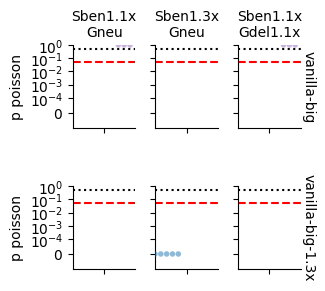

In [11]:
bins = [-np.inf, 0.005, 0.01, 0.05, 0.1, np.inf]
labels = ["<0.005", "<0.01", "<0.05", "<0.1", "ns"]

for y in ("p_poisson",):
    display(HTML(f"<h1>{y=}</h1>"))

    data = results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df["trt_n_downsample"].max()
        )
    ].copy()
    data["sig"] = pd.cut(
        data[y],
        bins=bins,
        labels=labels,
        include_lowest=True,
    )
    data["sig"] = data["sig"].cat.set_categories(labels, ordered=True)
    col_order = filter(
        set(data["trt_name_"]).__contains__,
        [
            "Sneu\nGneu",
            "Sben1.1x\nGneu",
            "Sben1.3x\nGneu",
            "Sben2x\nGneu",
            "Sben1.1x\nGdel1.1x",
            "Sben1.3x\nGdel1.1x",
            "Sben2x\nGdel2x",
        ],
    )
    col_order = [*col_order]
    with tp.teed(
        sns.catplot,
        data=data,
        y=y,
        col="trt_name_",
        row="source_name",
        hue="sig",
        col_order=col_order,
        legend=False,
        kind="swarm",
        dodge=True,
        margin_titles=True,
        alpha=0.5,
        height=1.6,
        aspect=0.7,
        size=4,
        teeplot_subdir=teeplot_subdir,
    ) as teed:
        teed.set_titles(col_template="{col_name}", row_template="{row_name}")
        for ax in teed.axes.flat:
            ax.set_yscale("symlog", linthresh=0.0001)
            ax.set_ylim(-0.0001, None)
            ax.axhline(0.5, color="black", linestyle=":")
            ax.axhline(0.05, color="red", linestyle="--")
            ax.tick_params(axis="x", rotation=-60)
            ax.set_xlabel("")
            ax.set_ylabel(y.replace("_", " "))

        teed.tight_layout()


teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+row=source-name+viz=catplot+y=num-focal-muts+ext=.pdf
teeplots/2025-05-19-freqscreen-summary/col=trt-name+kind=swarm+row=source-name+viz=catplot+y=num-focal-muts+ext=.png


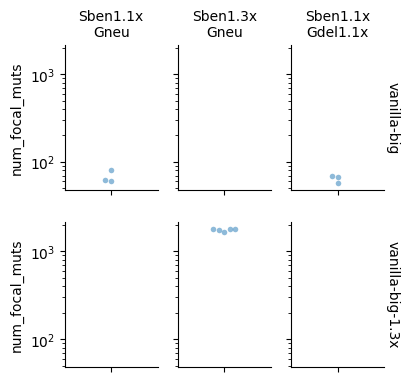

In [12]:
with tp.teed(
    sns.catplot,
    data=results_df[
        (results_df["trt_hsurf_bits"] == 0)
        & (
            results_df["trt_n_downsample"]
            == results_df["trt_n_downsample"].max()
        )
    ],
    y="num_focal_muts",
    col="trt_name_",
    row="source_name",
    col_order=col_order,
    legend=False,
    kind="swarm",
    dodge=True,
    margin_titles=True,
    alpha=0.5,
    height=2,
    aspect=0.7,
    size=4,
    teeplot_subdir=teeplot_subdir,
) as teed:
    teed.set_titles(col_template="{col_name}", row_template="{row_name}")
    for ax in teed.axes.flat:
        ax.set_yscale("log")

        ax.set_xlabel("")

    teed.tight_layout()
